<a href="https://colab.research.google.com/github/SungwonDS/GGMM/blob/main/GGMM_BIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. 이번 참 분포와 표본

사용하는 성분 밀도는

\[
g(x;\mu,a,b)=\frac{b}{2a\Gamma(1/b)}
\exp\left[-\left|\frac{x-\mu}{a}\right|^b\right]
\]

이고, 미리 정한 참 분포는

\[
p_{\mathrm{true}}(x)=
0.2g(x;-5,1.2,1.5)+0.3g(x;0,1.6,4)+0.5g(x;6,2,8)
\]

입니다. 성분들의 위치·척도·형상·가중치가 모두 다릅니다.
표본 수는 **5,000**, 표본 생성 시드는 **20260912**입니다.
추정기는 참 K=3, 참 파라미터, 성분 라벨과 참 밀도를 받지 않습니다.
한 번 뽑은 X 전체로 초기화·적합·선택을 수행합니다.
VGM에도 같은 X를 주며, VGM의 적합값은 GGMM에 전달하지 않습니다.

In [2]:
%pip install -q numpy scipy scikit-learn pandas matplotlib threadpoolctl

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


## 2. 왜 이 K를 선택하는가

먼저 각 후보 K에서 표본의 **로그우도**를 크게 만듭니다.
로그우도는 "이 분포가 주어진 관측값들을 얼마나 잘 설명하는가"를 수치로 나타냅니다.
성분을 더 쓰면 설명력을 높일 기회도 늘기 때문에, 성분 수의 비용을 함께 계산합니다.

\[
\mathrm{BIC}_K=-2\hat\ell_K+(4K-1)\log n.
\]

**BIC가 가장 작은 후보를 선택합니다.** 가중치에는 K−1개, 위치·척도·형상에는
각각 K개의 자유 파라미터가 있어 합계가 4K−1입니다.
K를 하나 늘리는 비용은 4log n이고, n=5000에서는 로그우도가 약 17.03보다
더 증가해야 큰 K의 BIC가 작아집니다. 이것은 선택식의 설명용 계산입니다.

한 성분이 관측점 하나에 지나치게 좁게 몰리는 우도 퇴화를 막기 위해
**a ≥ 0.001 × 표본 전체의 표준편차**를 사용합니다. b에는 임의 상한이나
b=2를 선호하는 벌점을 두지 않습니다. 척도 하한은 명시적인 수치 설정이며,
모든 데이터에 맞는 이론적 정답은 아닙니다. 뒤에서 하한을 바꾼 결과도 보여 줍니다.

Kmax=10은 탐색 상한입니다. BIC는 실제로 얻은 수치 적합값으로 계산되므로
전역 최적해나 참 K 복원을 보장하지 않습니다. 점수와 함께 종료 상태를 확인하세요.

## 3. 실험 코드 준비

다음 두 셀은 이 노트북에 포함된 추정기와 실험 함수를 준비합니다.
표본을 정렬해 구성한 그룹에서 출발점을 만들며 GGMM 초기화에는 난수를 사용하지 않습니다.
코드 세부를 수정하지 않아도 아래의 실행 셀로 결과를 볼 수 있습니다.

In [3]:
%%writefile ggmm_simple_bic.py
"""Independent, single-sample GGMM: bounded-scale likelihood fits + BIC.

No CDF objective, DKW selection, shape penalty, b upper bound, random
initialization, held-out sample, or fitted GMM input. This is numerical local
maximum likelihood, not a variational Bayesian GGMM or guaranteed global MLE.
"""
from dataclasses import dataclass, asdict
from time import perf_counter
import numpy as np
from scipy.optimize import minimize, brentq
from scipy.special import gammaln, digamma, logsumexp
from scipy.stats import gennorm


@dataclass(frozen=True)
class SimpleGGMMConfig:
    max_components: int = 10
    scale_floor_relative: float = 1e-3  # a_min / sample population SD
    max_iter: int = 1500
    ftol: float = 1e-10
    gtol: float = 1e-5


@dataclass
class Mixture:
    weights: np.ndarray
    means: np.ndarray
    scales: np.ndarray
    shapes: np.ndarray

    def __post_init__(self):
        for name in ('weights', 'means', 'scales', 'shapes'):
            setattr(self, name, np.asarray(getattr(self, name), float))
        if (self.weights.ndim != 1 or len(self.weights) == 0
                or any(getattr(self, p).shape != self.weights.shape
                       for p in ('means', 'scales', 'shapes'))
                or not all(np.isfinite(getattr(self, p)).all()
                           for p in ('weights', 'means', 'scales', 'shapes'))
                or np.any(self.weights <= 0) or not np.isclose(self.weights.sum(), 1)
                or np.any(self.scales <= 0) or np.any(self.shapes <= 0)):
            raise ValueError('Invalid mixture parameters.')

    @property
    def k(self):
        return len(self.weights)

    @property
    def sigmas(self):
        q = 1 / self.shapes
        with np.errstate(over='ignore'):
            return np.exp(np.log(self.scales) + .5 * (
                gammaln(1 + 3*q) - gammaln(1 + q) - np.log(3.)))

    def component_logpdf(self, x):
        return component_terms(np.asarray(x).reshape(-1), self.means,
                               np.log(self.scales), np.log(self.shapes))[0]

    def logpdf(self, x):
        return logsumexp(self.component_logpdf(x) + np.log(self.weights), axis=1)

    def pdf(self, x):
        return np.exp(self.logpdf(x))

    def cdf(self, x):
        return (gennorm.cdf(np.asarray(x).reshape(-1, 1), self.shapes,
                            loc=self.means, scale=self.scales) * self.weights).sum(axis=1)

    def component_ppf(self, p, labels):
        labels = np.asarray(labels, int)
        return gennorm.ppf(p, self.shapes[labels], loc=self.means[labels],
                           scale=self.scales[labels])

    def payload(self):
        return {p: getattr(self, p).tolist() for p in ('weights','means','scales','shapes')}

    def formula(self, digits=6):
        """g(x;mu,a,b) parameterization; rounded for display only."""
        f = lambda v: format(float(v), f'.{digits}g')
        return ' + '.join(f'{f(w)} g(x; {f(m)}, {f(a)}, {f(b)})'
                         for w,m,a,b in zip(self.weights,self.means,self.scales,self.shapes))


def unpack(theta, k):
    logits = np.r_[theta[:k-1], 0.]
    lw = logits - logsumexp(logits)
    return lw, theta[k-1:2*k-1], theta[2*k-1:3*k-1], theta[3*k-1:]


def pack(model):
    return np.r_[np.log(model.weights[:-1]/model.weights[-1]), model.means,
                 np.log(model.scales), np.log(model.shapes)]


def component_terms(x, mu, la, eta):
    with np.errstate(over='raise', invalid='raise', under='ignore'):
        b, q = np.exp(eta), np.exp(-eta)
        if np.any(b == 0) or np.any(q == 0):
            raise FloatingPointError('Shape cannot be represented.')
        norm = -np.log(2.) - la - gammaln(1 + q)
        dc = q * digamma(1 + q)
    if not np.isfinite(norm).all() or not np.isfinite(dc).all():
        raise FloatingPointError('Shape normalizer cannot be represented.')
    delta = x[:, None] - mu
    with np.errstate(divide='ignore', over='ignore', invalid='ignore', under='ignore'):
        lr = np.log(np.abs(delta)) - la
        lt = b * lr
        lp = norm - np.exp(lt)
    if np.isnan(lp).any():
        raise FloatingPointError('Invalid component density.')
    return lp, delta, lr, lt, dc


def nll_gradient(theta, x, k):
    """Mean NLL and exact derivatives where location derivatives exist.

    For b<=1, x=mu is nonsmooth; a zero location subgradient/convention is
    used at exact equality and this event is reported. No exponent clipping.
    """
    lw, mu, la, eta = unpack(theta, k)
    lp, delta, lr, lt, dc = component_terms(x, mu, la, eta)
    joint = lp + lw
    denom = logsumexp(joint, axis=1)
    if not np.isfinite(denom).all():
        raise FloatingPointError('Nonfinite mixture log density at an observation.')
    log_r = joint - denom[:, None]
    r = np.exp(log_r)
    with np.errstate(over='raise', invalid='raise', divide='ignore', under='ignore'):
        valid = np.isfinite(joint) & np.isfinite(lt)
        log_rbt = np.full_like(log_r, -np.inf)
        np.add(log_r + eta, lt, out=log_rbt, where=valid)
        rbt = np.exp(log_rbt)
        log_location = np.full_like(log_rbt, -np.inf)
        np.subtract(log_rbt, np.log(np.abs(delta)), out=log_location, where=delta != 0)
        location = np.sign(delta)*np.exp(log_location)
        shape_term = np.zeros_like(rbt)
        np.multiply(rbt, lr, out=shape_term, where=rbt != 0)
        grad = np.r_[np.exp(lw[:-1])-r.mean(axis=0)[:-1], -location.mean(axis=0),
                     (r-rbt).mean(axis=0), (shape_term-r*dc).mean(axis=0)]
    if not np.isfinite(grad).all():
        raise FloatingPointError('Nonfinite likelihood derivative.')
    return float(-denom.mean()), grad


def initial_shape(group):
    """Match mean absolute deviation / SD; fallback only if moment equation fails.

    The theoretical ratio increases from 0 to sqrt(3)/2. A finite sample's
    moment ratio can lie outside that interval. The b=2 fallback is a starting
    point, not a shape restriction or representative-shape assertion.
    """
    mu, sd = float(np.mean(group)), float(np.std(group))
    ratio = float(np.mean(np.abs(group-mu))/sd) if sd > 0 else np.nan
    if len(group) < 4 or not 0 < ratio < np.sqrt(3)/2:
        return 2., True
    def residual(eta):
        q = np.exp(-eta)
        return .5*np.log(3)-np.log(2)+gammaln(1+2*q)-.5*(
            gammaln(1+q)+gammaln(1+3*q))-np.log(ratio)
    lo, hi = -1., 1.
    while residual(lo) > 0 and lo > -16:
        lo -= 1
    while residual(hi) < 0 and hi < 24:
        hi += 1
    if residual(lo) * residual(hi) > 0:
        return 2., True
    return float(np.exp(brentq(residual, lo, hi))), False


def initializations(x, k, floor):
    """Two deterministic partitions, no density model fitted during initialization."""
    quantile = np.minimum(np.arange(len(x))*k//len(x), k-1)
    centers = np.quantile(x, (np.arange(k)+.5)/k)
    labels = None
    for _ in range(100):
        distance = (x[:, None]-centers)**2
        new = distance.argmin(axis=1)
        counts = np.bincount(new, minlength=k)
        for j in np.flatnonzero(counts == 0):
            residual = distance[np.arange(len(x)), new].copy()
            residual[counts[new] <= 1] = -np.inf
            i = int(np.argmax(residual))
            counts[new[i]] -= 1
            new[i] = j
            counts[j] += 1
        if labels is not None and np.array_equal(new, labels):
            break
        labels = new
        centers = np.array([x[labels == j].mean() for j in range(k)])
    partitions = [('quantile', quantile)]
    if not np.array_equal(labels, quantile):
        partitions.append(('lloyd', labels))
    for name, groups in partitions:
        parts = [x[groups == j] for j in range(k)]
        bs = [initial_shape(p) for p in parts]
        b = np.array([t[0] for t in bs])
        sigma = np.array([max(p.std(), floor) for p in parts])
        la = np.log(sigma) + .5*(np.log(3)+gammaln(1+1/b)-gammaln(1+3/b))
        a = np.exp(np.maximum(la, np.log(floor)))
        yield name, Mixture(np.array([len(p) for p in parts])/len(x),
                            np.array([p.mean() for p in parts]), a, b), sum(t[1] for t in bs)


class SimpleGGMM:
    def __init__(self, config=None):
        self.config = config or SimpleGGMMConfig()

    def fit(self, X):
        cfg = self.config
        x = np.asarray(X, float)
        if x.ndim == 2 and x.shape[1] == 1:
            x = x[:, 0]
        if x.ndim != 1 or len(x) < 4 or not np.isfinite(x).all():
            raise ValueError('Provide one finite continuous sample, with at least four observations.')
        if (not isinstance(cfg.max_components, int) or cfg.max_components < 1
                or not np.isfinite(cfg.scale_floor_relative) or cfg.scale_floor_relative <= 0
                or cfg.max_iter < 1 or not 0 < cfg.ftol < 1 or not 0 < cfg.gtol < 1):
            raise ValueError('Invalid configuration.')
        start = perf_counter()
        self.center_, self.unit_ = float(np.mean(x)), float(np.std(x))
        if not np.isfinite(self.unit_) or self.unit_ <= 0:
            raise ValueError('Constant or unrepresentable range: use a separate constant-column handler.')
        z = np.sort((x-self.center_)/self.unit_)
        if not np.isfinite(z).all():
            raise ValueError('Rescale the observations before fitting.')
        self.a_min_ = cfg.scale_floor_relative*self.unit_
        self.starts_, self.selection_, self.models_ = [], [], {}
        upper = min(cfg.max_components, len(np.unique(z)), len(z))
        previous_ll = -np.inf
        for k in range(1, upper+1):
            tick = perf_counter()
            bounds = [(None, None)]*(2*k-1) + [(np.log(cfg.scale_floor_relative), None)]*k + [(None, None)]*k
            candidates = []
            for name, initial, fallback_count in initializations(z, k, cfg.scale_floor_relative):
                best = [np.inf, None]
                rejected = [0]
                def objective(theta):
                    try:
                        value, grad = nll_gradient(theta, z, k)
                        if value < best[0]:
                            best[:] = value, theta.copy()
                        return value, grad
                    except (FloatingPointError, ValueError):
                        rejected[0] += 1
                        return np.inf, np.zeros_like(theta)
                theta0 = pack(initial)
                objective(theta0)
                opt = minimize(objective, theta0, jac=True, method='L-BFGS-B', bounds=bounds,
                               options=dict(maxiter=cfg.max_iter, ftol=cfg.ftol, gtol=cfg.gtol, maxls=50))
                theta = best[1]
                if theta is None:
                    self.starts_.append(dict(K=k, start=name, finite=False, converged=False,
                                             message='No finite likelihood', rejected_steps=rejected[0]))
                    continue
                value, grad = nll_gradient(theta, z, k)
                # Returning the best visited point avoids discarding a better finite trial.
                # If it differs from the optimizer endpoint, do not claim convergence.
                at_endpoint = bool(np.allclose(theta, opt.x, rtol=1e-10, atol=1e-10))
                for j in range(2*k-1, 3*k-1):
                    if theta[j] <= np.log(cfg.scale_floor_relative)+1e-8 and grad[j] > 0:
                        grad[j] = 0
                lw, mu, la, eta = unpack(theta, k)
                order = np.argsort(mu)
                try:
                    model = Mixture(np.exp(lw)[order], (self.center_+self.unit_*mu)[order],
                                    (self.unit_*np.exp(la))[order], np.exp(eta)[order])
                except ValueError as exc:
                    self.starts_.append(dict(K=k, start=name, finite=False, converged=False,
                        message=f'Unrepresentable final mixture: {exc}', rejected_steps=rejected[0]))
                    continue
                ll = float(-len(z)*(value+np.log(self.unit_)))
                row = dict(K=k, start=name, finite=True, log_likelihood=ll,
                           BIC=-2*ll+(4*k-1)*np.log(len(z)), converged=bool(opt.success and at_endpoint),
                           projected_gradient=float(np.max(np.abs(grad))), iterations=int(opt.nit),
                           message=str(opt.message), best_is_endpoint=at_endpoint,
                           rejected_steps=rejected[0], initial_shapes=initial.shapes.tolist(),
                           moment_fallback_components=int(fallback_count),
                           a_floor_hits=int(np.sum(model.scales <= self.a_min_*(1+1e-6))),
                           max_b=float(model.shapes.max()), min_b=float(model.shapes.min()),
                           nonsmooth_coincidences=int(np.sum((z[:, None] == mu) & (np.exp(eta) <= 1))))
                self.starts_.append(row)
                candidates.append((row, model))
            if not candidates:
                self.selection_.append(dict(K=k, finite=False, converged=False, BIC=np.inf))
                continue
            row, model = min(candidates, key=lambda item: item[0]['BIC'])
            row = row.copy()
            row.update(seconds=perf_counter()-tick,
                       likelihood_decreased=bool(row['log_likelihood'] < previous_ll-1e-5))
            previous_ll = max(previous_ll, row['log_likelihood'])
            self.models_[k] = model
            self.selection_.append(row)
        finite = [r for r in self.selection_ if r['finite']]
        if not finite:
            raise RuntimeError('All fits failed; inspect starts_.')
        winner = min(finite, key=lambda r: r['BIC'])
        self.n_components_ = winner['K']
        self.density_ = self.models_[self.n_components_]
        for r in self.selection_:
            r['delta_BIC'] = r['BIC']-winner['BIC']
            r['selected'] = r['K'] == self.n_components_
        self.diagnostics_ = dict(n=len(x), selected_K=self.n_components_, config=asdict(cfg),
            scale_floor_original_units=self.a_min_, selected_converged=winner['converged'],
            any_K_nonconverged=any(not r['converged'] for r in self.selection_),
            any_likelihood_decrease=any(r.get('likelihood_decreased',False) for r in self.selection_),
            selected_at_Kmax=self.n_components_ == upper,
            status='numerical_local_fit; no global optimum or true-K guarantee', seconds=perf_counter()-start)
        return self

    def predict_proba(self, X):
        joint = self.density_.component_logpdf(X) + np.log(self.density_.weights)
        denominator = logsumexp(joint, axis=1)
        if not np.isfinite(denominator).all():
            raise FloatingPointError('Posterior probabilities cannot be represented for these values.')
        return np.exp(joint-denominator[:, None])


Writing ggmm_simple_bic.py


In [4]:
%%writefile run_simple_bic_demo.py
"""One declared synthetic example: sample-only GGMM K selection vs VGM.

Truth is passed to generation and POST-FIT evaluation only. All reported
densities are normalized plug-in mixtures, including sklearn's VGM comparator.
"""
from pathlib import Path
from dataclasses import asdict, replace
from datetime import datetime, timezone
from time import perf_counter
import hashlib
import json
import platform
import warnings
import numpy as np
import pandas as pd
import scipy
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss
from scipy.special import gammaln
from scipy.stats import gennorm
from sklearn.mixture import BayesianGaussianMixture
from threadpoolctl import threadpool_limits
from ggmm_simple_bic import Mixture, SimpleGGMM, SimpleGGMMConfig


TRUTH_PARAMETERS = dict(weights=[.2,.3,.5], means=[-5.,0.,6.],
                        scales=[1.2,1.6,2.], shapes=[1.5,4.,8.])
SAMPLE_SIZE = 5000
SAMPLE_SEED = 20260912
VGM_SEED = 27


def sample_mixture(truth, n, seed):
    rng = np.random.default_rng(seed)
    labels = rng.choice(truth.k, size=n, p=truth.weights)
    return gennorm.rvs(truth.shapes[labels], loc=truth.means[labels],
                       scale=truth.scales[labels], random_state=rng)


def _points(model, tail):
    probabilities = [tail,1e-7,1e-5,.001,.01,.05,.1,.25,.5,.75,.9,.95,.99,.999,1-1e-5,1-1e-7,1-tail]
    p = np.tile(probabilities, model.k)
    labels = np.repeat(np.arange(model.k), len(probabilities))
    return np.unique(np.r_[model.component_ppf(p, labels), model.means,
                           model.means-model.scales, model.means+model.scales])


def density_errors(truth, fitted, tail=1e-9, atol=1e-7, rtol=1e-5):
    """Post-fit IAE/ISE: adaptive 32/64-node panels and omitted-tail bounds.

    Quadrature errors are estimates, not formal interval arithmetic bounds.
    The true density is never used for K selection or any fitting setting.
    """
    points = np.unique(np.r_[_points(truth,tail), _points(fitted,tail)])
    if not np.isfinite(points).all():
        raise FloatingPointError('Evaluation quantiles cannot be represented.')
    left,right = points[:-1],points[1:]
    n_panels = len(left)
    depth = np.zeros(n_panels,int)
    total,error = np.zeros(2),np.zeros(2)
    unresolved = 0
    def panel(l,r,order):
        nodes,weights = leggauss(order)
        mid,half = l/2+r/2,(r-l)/2
        xx = mid[:,None]+half[:,None]*nodes
        delta = (fitted.pdf(xx.ravel())-truth.pdf(xx.ravel())).reshape(xx.shape)
        return np.c_[np.abs(delta)@weights, delta**2@weights]*half[:,None]
    while len(left):
        low, high = panel(left,right,32), panel(left,right,64)
        err = np.abs(high-low)
        good = np.all(err <= atol/n_panels/(2.**depth[:,None])+rtol*np.abs(high),axis=1)
        stopped = depth >= 12
        accept = good|stopped
        total += high[accept].sum(axis=0)
        error += err[accept].sum(axis=0)
        unresolved += int(np.sum(stopped&~good))
        ll,rr,dd = left[~accept],right[~accept],depth[~accept]
        mid = ll/2+rr/2
        left,right,depth = np.r_[ll,mid],np.r_[mid,rr],np.r_[dd+1,dd+1]
    lo,hi = points[0],points[-1]
    def omitted(model):
        return float(np.clip(model.cdf([lo])[0]+1-model.cdf([hi])[0],0,1))
    def peak(model):
        return float(np.sum(model.weights*np.exp(-np.log(2)-np.log(model.scales)-gammaln(1+1/model.shapes))))
    tt,tf = omitted(truth),omitted(fitted)
    return dict(IAE=float(total[0]), ISE=float(total[1]),
        IAE_quadrature_error=float(error[0]), ISE_quadrature_error=float(error[1]),
        IAE_omitted_tail_upper=tt+tf, ISE_omitted_tail_upper=peak(truth)*tt+peak(fitted)*tf,
        quadrature_tolerance_met=bool(np.all(error <= atol+rtol*np.abs(total))),
        unresolved_panels=unresolved, integration_left=float(lo), integration_right=float(hi))


def fit_vgm(x, max_components=10):
    """RDT-style prior and active threshold; larger convergence budget disclosed."""
    tick = perf_counter()
    fitted = BayesianGaussianMixture(n_components=max_components, covariance_type='full',
        weight_concentration_prior_type='dirichlet_process', weight_concentration_prior=.001,
        init_params='kmeans', n_init=1, max_iter=1500, tol=1e-3, reg_covar=1e-6, random_state=VGM_SEED)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        fitted.fit(x.reshape(-1,1))
    seconds = perf_counter()-tick
    w,mu,a = fitted.weights_,fitted.means_[:,0],np.sqrt(2*fitted.covariances_[:,0,0])
    full = Mixture(w/w.sum(),mu,a,np.full(len(w),2.))
    mask = w > .005
    active = Mixture(w[mask]/w[mask].sum(),mu[mask],a[mask],np.full(mask.sum(),2.))
    diagnostic = dict(converged=bool(fitted.converged_),iterations=int(fitted.n_iter_),
        seconds=seconds,active_K=int(mask.sum()),max_components=max_components,
        active_threshold=.005,inactive_mass=float(w[~mask].sum()),
        settings=fitted.get_params(), warnings=[str(v.message) for v in caught],
        comparison_note='Raw X; RDT-style DP prior/threshold; max_iter raised from 100 to 1500.')
    return full,active,diagnostic


def parameter_table(model):
    return pd.DataFrame(dict(component=np.arange(1,model.k+1),weight=model.weights,
                             mu=model.means,a=model.scales,b=model.shapes,
                             sigma_derived=model.sigmas))


def make_figures(x, truth, fit, vgm, selection, out):
    grid = np.linspace(min(x.min(),_points(truth,1e-6).min()),
                       max(x.max(),_points(truth,1e-6).max()),3000)
    fig,axes = plt.subplots(1,2,figsize=(13,4.6),sharex=True,sharey=True)
    for ax,model,color,title in [(axes[0],fit,'#c43c39',f'GGMM: selected K = {fit.k}'),
                                  (axes[1],vgm,'#2865b0',f'VGM: active K = {vgm.k} (weight > 0.005)')]:
        ax.hist(x,bins=85,density=True,color='#dce2e8',edgecolor='white',linewidth=.3,label=f'Observed sample (n={len(x):,})')
        ax.plot(grid,truth.pdf(grid),color='#1c2530',lw=2,ls='--',label='True density (evaluation only)')
        ax.plot(grid,model.pdf(grid),color=color,lw=2.3,label='Fitted mixture density')
        for j in range(model.k):
            ax.plot(grid,model.weights[j]*np.exp(model.component_logpdf(grid)[:,j]),color=color,lw=.8,alpha=.4)
        ax.set(xlabel='x',ylabel='Density',title=title)
        ax.legend(fontsize=8)
        ax.spines[['top','right']].set_visible(False)
    fig.tight_layout()
    path=out/'density_comparison.png';fig.savefig(path,dpi=170);plt.close(fig)
    fig,axes=plt.subplots(1,2,figsize=(11,4.2))
    axes[0].plot(selection.K,selection.BIC,'o-',color='#c43c39')
    selected=selection[selection.selected].iloc[0]
    axes[0].scatter([selected.K],[selected.BIC],s=130,color='#1c2530',zorder=5,
                    label=f'Selected K = {int(selected.K)}')
    axes[0].set(xlabel='Candidate K',ylabel='BIC (lower is better)',title='K selected from the same observed sample',xticks=selection.K)
    axes[0].legend()
    axes[1].plot(selection.K,selection.log_likelihood,'o-',color='#2865b0')
    axes[1].set(xlabel='Candidate K',ylabel='Log likelihood (higher is better)',
                title='Extra components must earn their BIC cost',xticks=selection.K)
    for ax in axes: ax.spines[['top','right']].set_visible(False)
    fig.tight_layout()
    path2=out/'k_selection.png';fig.savefig(path2,dpi=170);plt.close(fig)
    return [path,path2]


def run_demo(output_dir, run_sensitivity=True):
    out = Path(output_dir);out.mkdir(parents=True,exist_ok=True)
    truth = Mixture(**TRUTH_PARAMETERS)
    x = sample_mixture(truth,SAMPLE_SIZE,SAMPLE_SEED)
    np.save(out/'observed_sample.npy',x)
    cfg=SimpleGGMMConfig()
    print('Fitting GGMM candidates K=1,...,10 using X only...',flush=True)
    with threadpool_limits(limits=1):
        ggmm=SimpleGGMM(cfg).fit(x)
        print(f'GGMM selected K={ggmm.n_components_}; {ggmm.diagnostics_["seconds"]:.2f} seconds',flush=True)
        full,active,vgm_diag=fit_vgm(x,cfg.max_components)
        rows=[]
        for name,model,seconds,converged in [
            ('GGMM + BIC',ggmm.density_,ggmm.diagnostics_['seconds'],ggmm.diagnostics_['selected_converged']),
            ('VGM active mixture',active,vgm_diag['seconds'],vgm_diag['converged']),
            ('VGM full mixture',full,vgm_diag['seconds'],vgm_diag['converged'])]:
            rows.append(dict(model=name,K=model.k,**density_errors(truth,model),fit_seconds=seconds,
                             converged=converged,sample_log_likelihood=float(model.logpdf(x).sum())))
        comparison=pd.DataFrame(rows)
        selection=pd.DataFrame(ggmm.selection_)
        parameters=parameter_table(ggmm.density_)
        comparison.to_csv(out/'comparison.csv',index=False)
        selection.to_csv(out/'k_selection.csv',index=False)
        parameters.to_csv(out/'estimated_parameters.csv',index=False)
        print(comparison[['model','K','IAE','ISE','fit_seconds','converged']].to_string(index=False),flush=True)
        figures=make_figures(x,truth,ggmm.density_,active,selection,out)
        failed=selection.loc[~selection.converged,'K'].tolist()
        if failed:
            print(f'Unconverged candidate K values: {failed}. BIC selection remains provisional.',flush=True)
        sensitivity=[]
        if run_sensitivity:
            for floor in [1e-4,1e-3,1e-2]:
                print(f'Same-sample scale-floor sensitivity: {floor:g}',flush=True)
                fitted=ggmm if floor == cfg.scale_floor_relative else SimpleGGMM(replace(cfg,scale_floor_relative=floor)).fit(x)
                sr=pd.DataFrame(fitted.selection_)
                sr.to_csv(out/f'k_selection_floor_{floor:g}.csv',index=False)
                sensitivity.append(dict(scale_floor_relative=floor,selected_K=fitted.n_components_,
                    selected_BIC=float(sr.loc[sr.selected,'BIC'].iloc[0]),
                    nearest_competitor_delta_BIC=float(sr.loc[~sr.selected,'delta_BIC'].min()),
                    a_floor_hits=int(sr.loc[sr.selected,'a_floor_hits'].iloc[0]),
                    selected_converged=fitted.diagnostics_['selected_converged'],
                    **density_errors(truth,fitted.density_),fit_seconds=fitted.diagnostics_['seconds']))
    sensitivity=pd.DataFrame(sensitivity)
    sensitivity.to_csv(out/'scale_floor_sensitivity.csv',index=False)
    formula='g(x; mu,a,b) = b/(2*a*Gamma(1/b)) * exp(-abs((x-mu)/a)**b)\n\n'
    formula+='True density:\n'+truth.formula(9)+'\n\nEstimated GGMM:\n'+ggmm.density_.formula(9)+'\n'
    (out/'estimated_formula.txt').write_text(formula,encoding='utf-8')
    models=dict(truth=truth.payload(),ggmm=ggmm.density_.payload(),vgm_full=full.payload(),vgm_active=active.payload())
    (out/'models.json').write_text(json.dumps(models,indent=2),encoding='utf-8')
    metadata=dict(created_utc=datetime.now(timezone.utc).isoformat(),sample_size=SAMPLE_SIZE,
        sample_seed=SAMPLE_SEED,vgm_seed=VGM_SEED,truth=TRUTH_PARAMETERS,
        sample_sha256=hashlib.sha256(x.tobytes()).hexdigest(),ggmm_config=asdict(cfg),
        ggmm_diagnostics=ggmm.diagnostics_,vgm_diagnostics=vgm_diag,
        versions=dict(python=platform.python_version(),numpy=np.__version__,scipy=scipy.__version__,
                      sklearn=sklearn.__version__,pandas=pd.__version__,matplotlib=matplotlib.__version__),
        fitting_contract='One X; no truth, labels, split, or validation input. No fitting RNG in GGMM.',
        code_hashes={name:hashlib.sha256(Path(__file__).with_name(name).read_bytes()).hexdigest()
                     for name in ['ggmm_simple_bic.py','run_simple_bic_demo.py']},
        limitations=['One predeclared example, not a distribution-wide performance claim.',
            'BIC uses local numerical fits in a nonregular constrained mixture family.',
            'GGMM+BIC and VGM differ in both distribution and estimation/selection.',
            'No CTGAN training or generated-table quality evaluation.'])
    (out/'metadata.json').write_text(json.dumps(metadata,indent=2,default=str),encoding='utf-8')
    (out/'initialization_log.json').write_text(json.dumps(ggmm.starts_,indent=2),encoding='utf-8')
    return dict(ggmm=ggmm,truth=truth,x=x,comparison=comparison,selection=selection,
                parameters=parameters,sensitivity=sensitivity,figures=figures,metadata=metadata)


if __name__ == '__main__':
    import argparse
    parser=argparse.ArgumentParser()
    parser.add_argument('--output-dir',default='results/ggmm_simple_bic')
    parser.add_argument('--skip-sensitivity',action='store_true')
    args=parser.parse_args()
    result=run_demo(args.output_dir,not args.skip_sensitivity)
    print(result['selection'][['K','BIC','delta_BIC','converged','a_floor_hits','max_b']].to_string(index=False))
    print(result['ggmm'].density_.formula())


Writing run_simple_bic_demo.py


## 4. 같은 표본에 GGMM과 VGM 적합

이 셀이 본 실험과 척도 하한 민감도 점검을 실행합니다.
민감도 점검에도 같은 표본을 사용하고, 참 밀도 오차로 기본 하한을 다시 고르지 않습니다.
실행 환경에 따라 시간이 달라질 수 있습니다.

In [5]:
from pathlib import Path
from IPython.display import Image, Markdown, display
from run_simple_bic_demo import run_demo

OUTPUT_DIR = Path("ggmm_simple_bic_results")
result = run_demo(OUTPUT_DIR, run_sensitivity=True)
print("결과 폴더:", OUTPUT_DIR.resolve())

Fitting GGMM candidates K=1,...,10 using X only...
GGMM selected K=3; 229.56 seconds
             model  K      IAE      ISE  fit_seconds  converged
        GGMM + BIC  3 0.029223 0.000092   229.564234       True
VGM active mixture  5 0.108209 0.001250     1.935891       True
  VGM full mixture 10 0.108488 0.001252     1.935891       True
Unconverged candidate K values: [8, 9, 10]. BIC selection remains provisional.
Same-sample scale-floor sensitivity: 0.0001
Same-sample scale-floor sensitivity: 0.001
Same-sample scale-floor sensitivity: 0.01
결과 폴더: D:\논병아리\GGMM\ggmm_simple_bic_results


## 5. 선택 K와 실제 추정식

아래 식의 숫자는 위에서 적합한 결과입니다. a와 b는 별도 파라미터이고,
표준편차는 이 두 값에서 계산할 수 있으므로 별도로 추정하는 변수가 아닙니다.

In [6]:
print("추정 GGMM 밀도식")
print(result["ggmm"].density_.formula())
print("\n추정 파라미터")
display(result["parameters"])

추정 GGMM 밀도식
0.201703 g(x; -4.9882, 1.19189, 1.50518) + 0.306703 g(x; 0.0284772, 1.5861, 3.89738) + 0.491594 g(x; 5.99337, 2.02321, 8.84261)

추정 파라미터


,component,weight,mu,a,b,sigma_derived
0,1,0.201703,-4.988200,1.191885,1.505184,1.021217
1,2,0.306703,0.028477,1.586101,3.897380,0.925114
2,3,0.491594,5.993367,2.023213,8.842612,1.134340


## 6. K별 점수를 보고 선택 이유 확인

BIC와 최저점 대비 차이 ΔBIC를 확인하세요.
단순히 K=3이 나왔는지만 확인하기보다, 다른 K보다 점수가 얼마나 낮은지와
후보별 적합이 제대로 종료됐는지 함께 봐야 합니다.
수치 최적화가 불충분하면 해당 후보가 원래 가질 수 있는 설명력을 놓칠 수 있습니다.

In [7]:
display(result["selection"][["K", "log_likelihood", "BIC", "delta_BIC", "selected", "converged", "a_floor_hits", "max_b"]])
failed = result["selection"].loc[~result["selection"].converged, "K"].tolist()
if failed:
    print("수렴하지 않은 후보 K:", failed)
    print("현재 K는 계산된 후보 점수의 최솟값입니다. 미수렴 후보 때문에 선택 결론은 잠정적입니다.")

,K,log_likelihood,BIC,delta_BIC,selected,converged,a_floor_hits,max_b
0,1,-13777.280490,27580.112559,3131.797810,False,True,0,1.387691e+01
1,2,-12735.934720,25531.489792,1083.175043,False,True,0,8.841810e+00
2,3,-12177.312812,24448.314748,0.000000,True,True,0,8.842612e+00
3,4,-12175.128761,24478.015420,29.700672,False,True,0,5.282206e+00
4,5,-12172.481564,24506.789798,58.475050,False,True,0,4.176694e+06
5,6,-12171.948443,24539.792329,91.477581,False,True,0,1.436473e+01
6,7,-12168.156474,24566.277164,117.962415,False,True,0,6.020295e+00
7,8,-12165.350955,24594.734899,146.420150,False,False,0,1.579973e+06
8,9,-12163.877190,24625.856141,177.541392,False,False,0,4.255269e+03
9,10,-12172.894512,24677.959559,229.644811,False,False,0,3.321999e+02


수렴하지 않은 후보 K: [8, 9, 10]
현재 K는 계산된 후보 점수의 최솟값입니다. 미수렴 후보 때문에 선택 결론은 잠정적입니다.


## 7. 표본·참 분포·GGMM·VGM 비교

히스토그램은 관측된 표본을 보여 주며, 참 밀도 자체는 아닙니다.
IAE와 ISE는 **표본 적합이 끝난 후 참 밀도와 비교하는 오차**이고 작을수록 좋습니다.
참 밀도를 모르는 실제 데이터에서는 같은 의미로 계산할 수 없습니다.

VGM은 최대 성분 수 10, Dirichlet process 가중치 사전분포,
집중도 0.001을 기준으로 적합하며 가중치가 0.005보다 큰 성분을 유효 성분으로 셉니다.
전체 VGM 밀도와 유효 성분만 남겨 재정규화한 밀도는 구분해야 합니다.
표시된 비교 행·범례를 기준으로 해석하세요.
GGMM+BIC와 VGM은 추정 및 성분 선택법도 다르므로 이 비교만으로
Gaussian을 Generalized Gaussian으로 바꾼 효과를 분리할 수는 없습니다.

,model,K,IAE,ISE,fit_seconds,converged
0,GGMM + BIC,3,0.029223,0.000092,229.564234,True
1,VGM active mixture,5,0.108209,0.001250,1.935891,True
2,VGM full mixture,10,0.108488,0.001252,1.935891,True


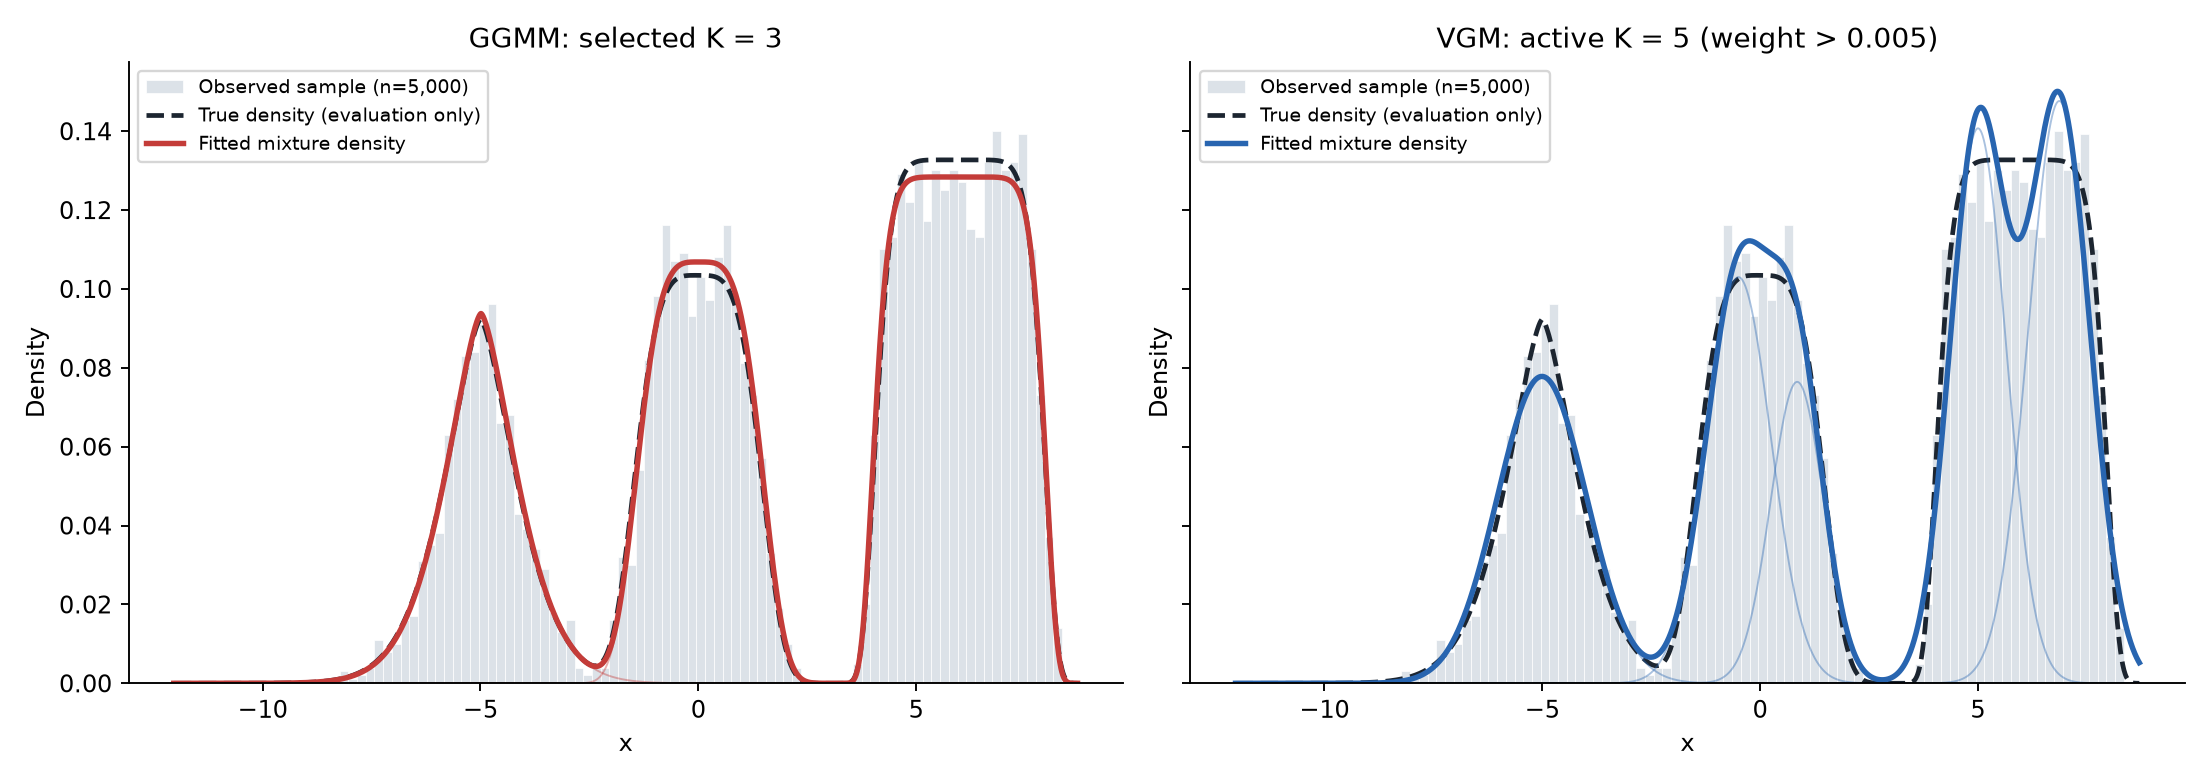

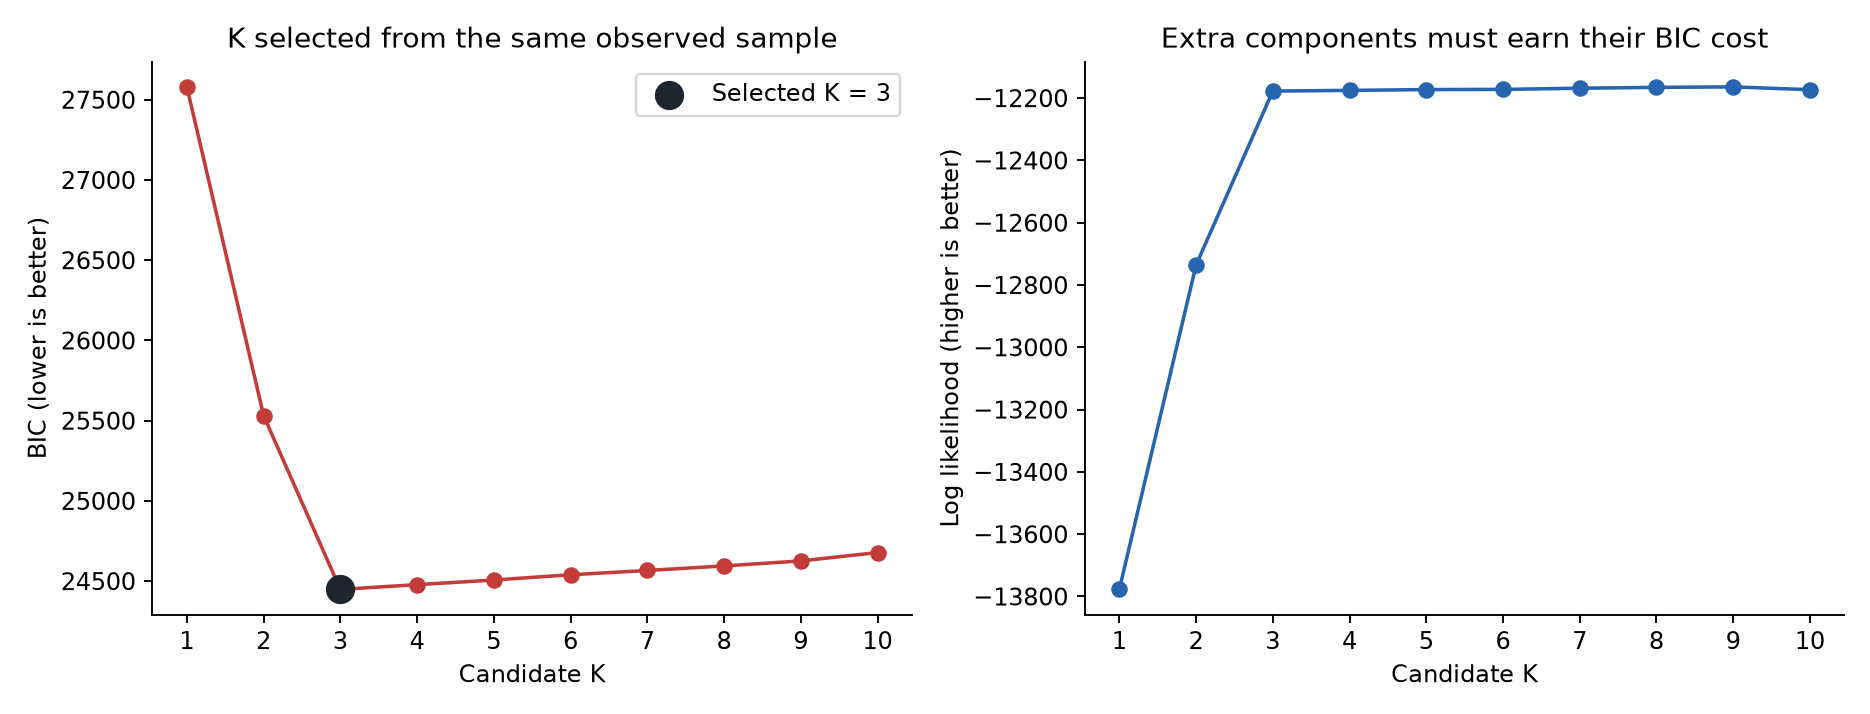

In [8]:
display(result["comparison"][["model", "K", "IAE", "ISE", "fit_seconds", "converged"]])
for figure_path in result["figures"]:
    display(Image(filename=str(figure_path)))

## 8. 척도 하한에 얼마나 민감한가

기본 하한의 계수를 바꿨을 때 선택 K·적합 점수·오차가 크게 달라지는지 확인합니다.
결과가 안정적이어도 모든 분포에서 안정적이라는 보장은 없습니다.
이 표는 하한의 영향을 공개하는 점검이며 참 밀도에 가장 잘 맞는 설정을 숨겨 고르는 절차가 아닙니다.

In [9]:
display(result["sensitivity"][["scale_floor_relative", "selected_K", "selected_BIC", "nearest_competitor_delta_BIC", "a_floor_hits", "selected_converged", "IAE", "ISE"]])

,scale_floor_relative,selected_K,selected_BIC,nearest_competitor_delta_BIC,a_floor_hits,selected_converged,IAE,ISE
0,0.0001,3,24448.314748,29.700672,0,True,0.029223,0.000092
1,0.0010,3,24448.314748,29.700672,0,True,0.029223,0.000092
2,0.0100,3,24448.314748,29.700672,0,True,0.029223,0.000092


## 9. 생성기와 연결할 때 남은 것

적합한 GGMM은 이후 **성분에 맞춘 연속값 하나 + 성분 번호의 one-hot** 형식으로
연결할 수 있습니다.

## 참고한 근거

- [GGMM 원논문](https://eurasip.org/Proceedings/Eusipco/Eusipco2009/contents/papers/1569186944.pdf):
  성분별 형상을 가지는 GGMM과 우도 기반 추정. 이번 초기화·척도 하한·BIC 조합을 그대로 제시한 논문은 아닙니다.
- [SciPy의 GGD 정의](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gennorm.html):
  사용하는 대칭 일반화 가우시안 밀도와 파라미터 정의.
- [scikit-learn의 혼합모형 설명](https://scikit-learn.org/stable/modules/mixture.html):
  우도 퇴화, BIC 성분 선택과 변분 베이지안 추정의 차이.
- [RDT 공식 구현](https://raw.githubusercontent.com/sdv-dev/RDT/main/rdt/transformers/numerical.py):
  VGM 집중도 0.001, 유효 성분 임계값 0.005, 성분별 정규화의 구현 근거.
- [CTGAN 원논문](https://arxiv.org/html/1907.00503v2):
  연속형 변수를 성분별 정규화 값과 성분 정보로 표현하는 배경.

## 결과 다운로드 — 선택 사항

아래 셀의 `DOWNLOAD_RESULTS`를 `True`로 바꾸면 결과 폴더를 압축합니다.
Colab에서는 다운로드 창을 열고, 로컬 환경에서는 압축 파일 위치를 출력합니다.

In [10]:
DOWNLOAD_RESULTS = True
if DOWNLOAD_RESULTS:
    import shutil
    archive = shutil.make_archive(
        str(OUTPUT_DIR.resolve()), "zip", root_dir=OUTPUT_DIR
    )
    print("압축 파일:", archive)
    try:
        from google.colab import files
    except ImportError:
        print("로컬 실행 환경에서는 위 경로의 압축 파일을 사용하세요.")
    else:
        files.download(archive)

압축 파일: D:\논병아리\GGMM\ggmm_simple_bic_results.zip
로컬 실행 환경에서는 위 경로의 압축 파일을 사용하세요.


In [11]:
# 기존 result와 OUTPUT_DIR을 사용합니다. GGMM을 다시 적합하지 않습니다.
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display


def export_initialization_report(ggmm, output_dir):
    """Report actual retained starts; never infer the winner from rounded scores."""
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)
    names = {"quantile": "Quantile", "lloyd": "Lloyd"}
    selection = {int(row["K"]): row for row in ggmm.selection_}
    detail_rows, summary_rows, tex_rows = [], [], []

    def finite_fit(row):
        return (row is not None and bool(row.get("finite", False))
                and np.isfinite(row.get("log_likelihood", np.nan)))

    for k, selected in sorted(selection.items()):
        starts = {row["start"]: row for row in ggmm.starts_ if row["K"] == k}
        winner = selected.get("start") if finite_fit(selected) else None
        summary = {"K": k}
        latex_ll = {}
        for method in ("quantile", "lloyd"):
            row = starts.get(method)
            valid = finite_fit(row)
            if row is None:
                status = "동일 분할로 생략" if method == "lloyd" else "기록 없음"
                tex_value = "동일 분할"
            elif not valid:
                status = "유효 적합 실패"
                tex_value = "실패"
            else:
                status = "성공 종료" if row.get("converged", False) else "미수렴"
                tex_value = f"{row['log_likelihood']:.4f}"
                if not row.get("converged", False):
                    tex_value += r"\(^{\dagger}\)"
            chosen = method == winner
            detail_rows.append({
                "K": k, "초기화": names[method],
                "적합 후 로그우도": row["log_likelihood"] if valid else np.nan,
                "BIC": row.get("BIC", np.nan) if valid else np.nan,
                "종료 상태": status, "K 내 채택": chosen,
                "최종 K 선택": bool(chosen and selected.get("selected", False)),
                "종료 메시지": row.get("message", "") if row is not None else "",
                "초기 b": row.get("initial_shapes", []) if row is not None else [],
            })
            summary[f"{names[method]} 로그우도"] = row["log_likelihood"] if valid else np.nan
            summary[f"{names[method]} 종료"] = status
            latex_ll[method] = tex_value
        summary["채택 초기화"] = names.get(winner, "없음")
        summary["최종 K 선택"] = bool(selected.get("selected", False))
        summary_rows.append(summary)
        label = (rf"\(\mathbf{{{k}}}^{{*}}\)" if selected.get("selected", False) else str(k))
        tex_rows.append(" & ".join([label, latex_ll["quantile"], latex_ll["lloyd"],
                                    names.get(winner, "없음")]) + r" \\")

    detail = pd.DataFrame(detail_rows)
    summary = pd.DataFrame(summary_rows)
    detail.to_csv(out / "initialization_details.csv", index=False, encoding="utf-8-sig")
    summary.to_csv(out / "initialization_selection.csv", index=False, encoding="utf-8-sig")
    # The default experiment has 10 candidates. Paginate if its range is extended.
    pages = []
    for offset in range(0, len(tex_rows), 10):
        suffix = "" if len(tex_rows) <= 10 else f" ({offset // 10 + 1})"
        pages.append(
            r"\begin{frame}{K별로 채택된 초기화" + suffix + "}\n"
            r"  \small" + "\n"
            r"  두 초기화에서 출발해 각각 전체 표본으로 적합한 결과입니다." + "\n"
            r"  \begin{center}" + "\n"
            r"  \footnotesize\renewcommand{\arraystretch}{1.08}" + "\n"
            r"  \begin{tabular}{crrl}" + "\n"
            r"    \toprule" + "\n"
            r"    \(K\) & Quantile 로그우도 & Lloyd 로그우도 & 채택 초기화 \\" + "\n"
            r"    \midrule" + "\n"
            + "\n".join("    " + row for row in tex_rows[offset:offset+10]) + "\n"
            r"    \bottomrule" + "\n"
            r"  \end{tabular}" + "\n"
            r"  \end{center}" + "\n"
            r"  {\scriptsize 같은 \(K\)에서는 로그우도가 큰 결과를 채택합니다."
            r"  이후 \(K\) 간 비교에는 BIC를 사용합니다.\par" + "\n"
            r"  \(^{*}\): BIC로 선택된 최종 \(K\). "
            r"  \(^{\dagger}\): 미수렴. 동일 분할: 중복 초기화 생략.\par" + "\n"
            r"  종료 상태는 최적화기 기준이며 전역 최적성을 보장하지 않습니다.}" + "\n"
            r"  \note{Quantile과 Lloyd는 초기값 구성법입니다. 그룹을 고정한 채로 "
            r"성분을 따로 적합하는 것이 아닙니다. 초기값마다 전체 표본의 혼합 우도를 "
            r"최적화하고, 같은 K에서 더 큰 우도를 얻은 시작점을 채택합니다. "
            r"미수렴 결과도 코드의 선택 대상에 포함됩니다. 표시 전 정밀도의 점수로 "
            r"채택하며 정확히 동점이면 먼저 평가한 Quantile을 유지합니다.}" + "\n"
            r"\end{frame}" + "\n"
        )
    tex_path = out / "initialization_selection_frame.tex"
    tex_path.write_text("\n".join(pages), encoding="utf-8")
    return summary, detail, tex_path


# 이 아래부터 기존 실험의 메모리상 결과를 읽어 표를 표시합니다.
initialization_summary, initialization_details, initialization_tex = export_initialization_report(
    result["ggmm"], OUTPUT_DIR
)
print("각 K에서 채택된 초기화 — 로그우도는 초기값이 아니라 적합 후 값입니다.")
display(initialization_summary.round(6))
print("초기화별 상세 기록")
display(initialization_details.round(6))
print("같은 K에서는 로그우도가 큰 결과를 채택합니다. 정확히 동점이면 Quantile을 유지합니다.")
print("성공 종료는 최적화기의 종료 판정이며, 전역 최적해를 뜻하지 않습니다.")
print("LaTeX 슬라이드:", initialization_tex.resolve())
print("기존 결과 다운로드 셀에서 DOWNLOAD_RESULTS = True로 설정하면 표와 TeX도 ZIP에 포함됩니다.")


각 K에서 채택된 초기화 — 로그우도는 초기값이 아니라 적합 후 값입니다.


,K,Quantile 로그우도,Quantile 종료,Lloyd 로그우도,Lloyd 종료,채택 초기화,최종 K 선택
0,1,-13777.280490,성공 종료,NaN,동일 분할로 생략,Quantile,False
1,2,-12735.934721,성공 종료,-12735.934720,성공 종료,Lloyd,False
2,3,-12666.145715,성공 종료,-12177.312812,성공 종료,Lloyd,True
3,4,-12175.128761,성공 종료,-12175.128766,성공 종료,Quantile,False
4,5,-12172.481564,성공 종료,-12174.540095,성공 종료,Quantile,False
5,6,-12171.948443,성공 종료,-12173.137388,성공 종료,Quantile,False
6,7,-12169.637321,성공 종료,-12168.156474,성공 종료,Lloyd,False
7,8,-12165.350955,미수렴,-12167.511177,미수렴,Quantile,False
8,9,-12163.877190,미수렴,-12166.051568,미수렴,Quantile,False
9,10,-12176.808635,미수렴,-12172.894512,미수렴,Lloyd,False


초기화별 상세 기록


,K,초기화,적합 후 로그우도,BIC,종료 상태,K 내 채택,최종 K 선택,종료 메시지,초기 b
0,1,Quantile,-13777.280490,27580.112559,성공 종료,True,False,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,[2.0]
1,1,Lloyd,NaN,NaN,동일 분할로 생략,False,False,,[]
2,2,Quantile,-12735.934721,25531.489794,성공 종료,False,False,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,"[2.0, 3.165158356537666]"
3,2,Lloyd,-12735.934720,25531.489792,성공 종료,True,False,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,"[2.0, 6.686462965955936]"
4,3,Quantile,-12666.145715,25425.980554,성공 종료,False,False,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,"[2.0, 2.0, 10.282844315981288]"
5,3,Lloyd,-12177.312812,24448.314748,성공 종료,True,True,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,"[1.6440407758286195, 4.227252410794843, 13.331..."
6,4,Quantile,-12175.128761,24478.015420,성공 종료,True,False,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,"[2.067706023507182, 9.602486015580723, 1.18303..."
7,4,Lloyd,-12175.128766,24478.015429,성공 종료,False,False,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,"[1.6440407758286195, 4.227252410794843, 8.5270..."
8,5,Quantile,-12172.481564,24506.789798,성공 종료,True,False,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,"[1.6360902075251322, 3.186626829499091, 2.0, 9..."
9,5,Lloyd,-12174.540095,24510.906860,성공 종료,False,False,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,"[1.700158645198382, 1.660358260123102, 3.09715..."


같은 K에서는 로그우도가 큰 결과를 채택합니다. 정확히 동점이면 Quantile을 유지합니다.
성공 종료는 최적화기의 종료 판정이며, 전역 최적해를 뜻하지 않습니다.
LaTeX 슬라이드: D:\논병아리\GGMM\ggmm_simple_bic_results\initialization_selection_frame.tex
기존 결과 다운로드 셀에서 DOWNLOAD_RESULTS = True로 설정하면 표와 TeX도 ZIP에 포함됩니다.


표본 수 n: 5,000
커널: Gaussian | 커널 수: 5,000
대역폭 규칙: scott
대역폭 계수: 0.18205642
실제 대역폭 h: 0.81530539
KDE 전체 로그우도 (자연로그): -12660.866914
KDE 관측값당 평균 로그우도: -2.532173

KDE 적합시간: 0.000635초
로그우도 계산시간: 1.066343초
적합 + 로그우도 계산시간: 1.066978초

시간에는 데이터 준비, 출력 및 그래프 생성이 포함되지 않습니다.
로그우도는 적합에 사용한 동일 표본에서 계산했습니다.
대역폭은 Scott 규칙으로 정했으며, 훈련 로그우도를 최대화한 값은 아닙니다.


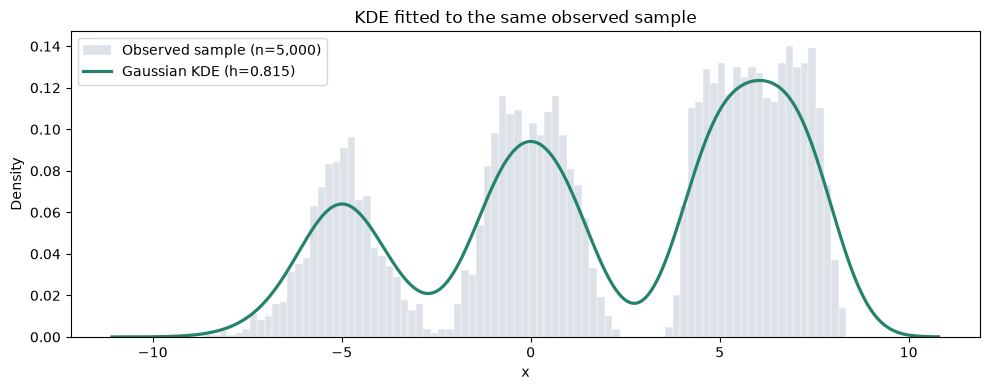

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from time import perf_counter

if "result" not in globals() or "x" not in result:
    raise RuntimeError('먼저 result = run_demo(...) 셀을 실행하세요.')

kde_x = np.asarray(result["x"], dtype=float).reshape(-1)

if (
    kde_x.size < 2
    or not np.isfinite(kde_x).all()
    or np.std(kde_x, ddof=1) <= 0
):
    raise ValueError(
        "KDE에는 유한한 관측값이 2개 이상이고 표본 분산이 양수여야 합니다."
    )

KDE_BW_METHOD = "scott"

# 1. KDE 적합시간 측정 — Scott 대역폭 계산 포함
start_fit = perf_counter()

kde = gaussian_kde(kde_x, bw_method=KDE_BW_METHOD)
kde_bandwidth = float(np.sqrt(kde.covariance[0, 0]))

kde_fit_seconds = perf_counter() - start_fit

# 2. 같은 표본의 로그우도 계산시간 측정
start_score = perf_counter()

kde_log_density = kde.logpdf(kde_x)
kde_log_likelihood = float(kde_log_density.sum())
kde_mean_log_likelihood = float(kde_log_density.mean())

kde_score_seconds = perf_counter() - start_score
kde_total_seconds = kde_fit_seconds + kde_score_seconds

# 3. 결과 출력
print(f"표본 수 n: {kde_x.size:,}")
print(f"커널: Gaussian | 커널 수: {kde.n:,}")
print(f"대역폭 규칙: {KDE_BW_METHOD}")
print(f"대역폭 계수: {kde.factor:.8f}")
print(f"실제 대역폭 h: {kde_bandwidth:.8f}")
print(f"KDE 전체 로그우도 (자연로그): {kde_log_likelihood:.6f}")
print(f"KDE 관측값당 평균 로그우도: {kde_mean_log_likelihood:.6f}")
print()
print(f"KDE 적합시간: {kde_fit_seconds:.6f}초")
print(f"로그우도 계산시간: {kde_score_seconds:.6f}초")
print(f"적합 + 로그우도 계산시간: {kde_total_seconds:.6f}초")
print()
print("시간에는 데이터 준비, 출력 및 그래프 생성이 포함되지 않습니다.")
print("로그우도는 적합에 사용한 동일 표본에서 계산했습니다.")
print("대역폭은 Scott 규칙으로 정했으며, 훈련 로그우도를 최대화한 값은 아닙니다.")

# 4. 시각화 — 위 시간 측정에서 제외
kde_grid = np.linspace(
    kde_x.min() - 3 * kde_bandwidth,
    kde_x.max() + 3 * kde_bandwidth,
    2000,
)

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    kde_x,
    bins=85,
    density=True,
    color="#dce2e8",
    edgecolor="white",
    linewidth=0.3,
    label=f"Observed sample (n={kde_x.size:,})",
)
ax.plot(
    kde_grid,
    kde(kde_grid),
    color="#26836b",
    linewidth=2.3,
    label=f"Gaussian KDE (h={kde_bandwidth:.3f})",
)
ax.set(
    xlabel="x",
    ylabel="Density",
    title="KDE fitted to the same observed sample",
)
ax.legend()
fig.tight_layout()
plt.show()

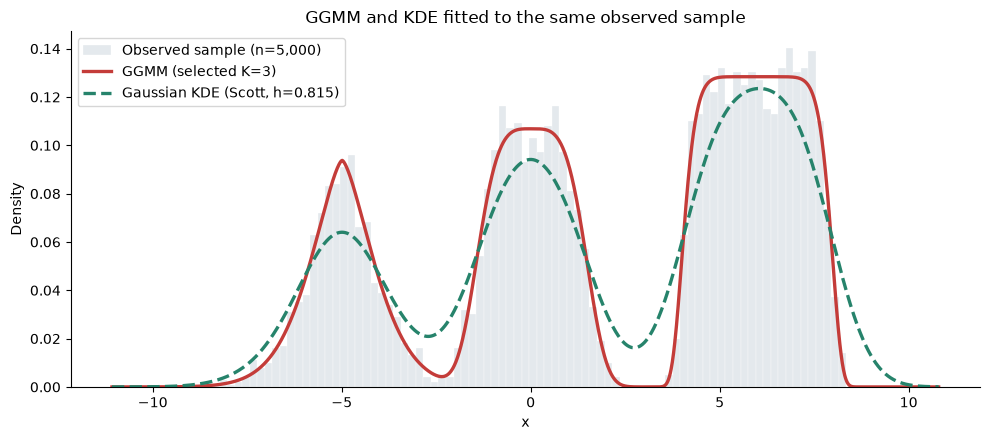

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 기존 실험 결과
x = np.asarray(result["x"], dtype=float)
ggmm = result["ggmm"].density_

# Gaussian KDE: Scott 대역폭
kde = gaussian_kde(x, bw_method="scott")
kde_bandwidth = float(np.sqrt(kde.covariance[0, 0]))

# 공통 그래프 범위
grid = np.linspace(
    x.min() - 3 * kde_bandwidth,
    x.max() + 3 * kde_bandwidth,
    2000,
)

# 밀도 계산
ggmm_density = ggmm.pdf(grid)
kde_density = kde(grid)

# 겹친 그래프
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.hist(
    x,
    bins=85,
    density=True,
    color="#dce2e8",
    edgecolor="white",
    linewidth=0.3,
    alpha=0.75,
    label=f"Observed sample (n={len(x):,})",
)

ax.plot(
    grid,
    ggmm_density,
    color="#c43c39",
    linewidth=2.4,
    label=f"GGMM (selected K={ggmm.k})",
)

ax.plot(
    grid,
    kde_density,
    color="#26836b",
    linewidth=2.4,
    linestyle="--",
    label=f"Gaussian KDE (Scott, h={kde_bandwidth:.3f})",
)

ax.set(
    xlabel="x",
    ylabel="Density",
    title="GGMM and KDE fitted to the same observed sample",
)

ax.legend()
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

전체 표본 수: 5,000 | GGMM 선택 K: 3
추출 시드: 20260914
선택된 인덱스 (0부터 시작): [4522, 3243, 1038]
선택된 관측값: [ 5.818552,  6.024767, -0.722823]
Scott 대역폭: 전체 표본 h=0.81530539, 3개 표본 h=3.08058450


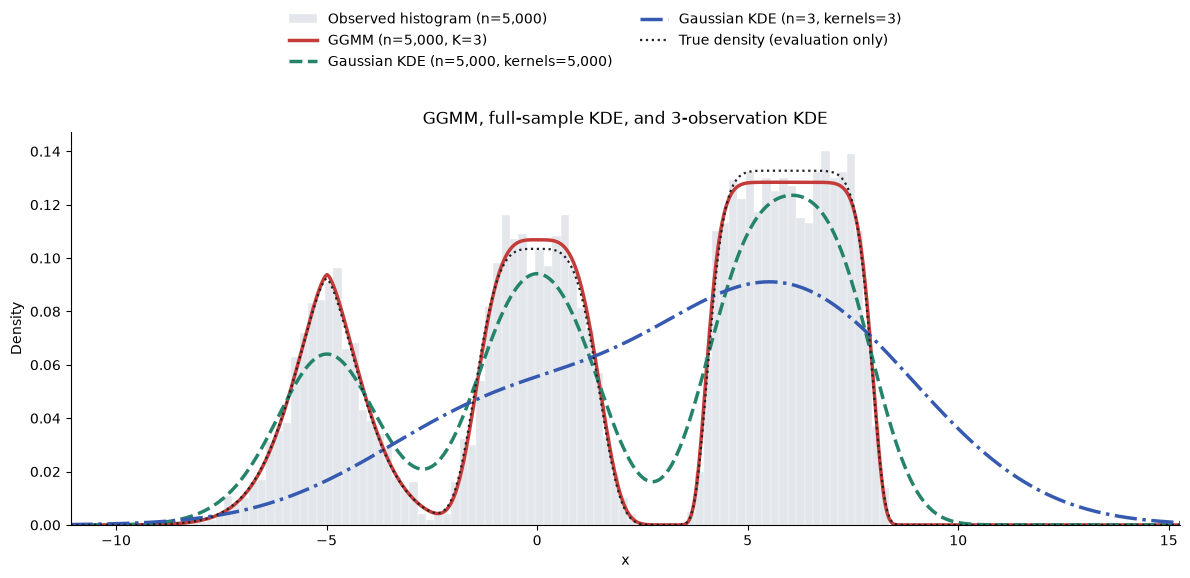

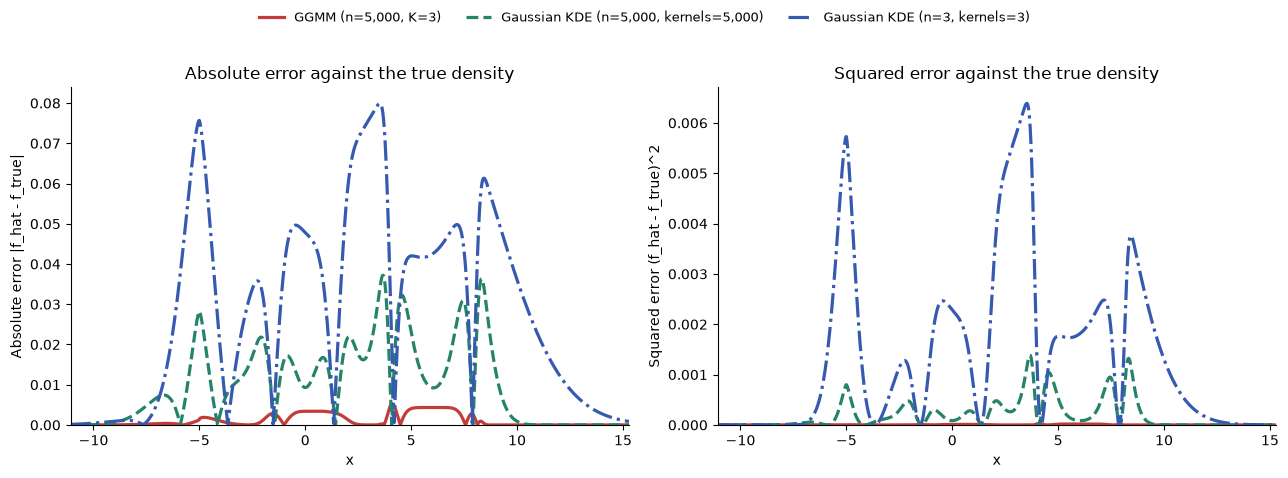

참 밀도와의 오차 지표 (IAE, ISE 모두 작을수록 좋음)


,Method,IAE,ISE
0,"GGMM (n=5,000, K=3)",0.029223,0.000092
1,"Gaussian KDE (n=5,000, kernels=5,000)",0.264091,0.005210
2,"Gaussian KDE (n=3, kernels=3)",0.759495,0.036073


적분 구간 [-24.0350, 23.7501], 4,000개 격자점의 사다리꼴 근사입니다.
유한 구간의 근사값이며, 구간 밖 꼬리 오차는 포함하지 않습니다.
n=3 KDE는 뽑힌 3개 값만 사용합니다. 전체 표본에 성분 3개를 최적화한 모델과는 다릅니다.


In [14]:

from pathlib import Path
from scipy.stats import gaussian_kde
from scipy.integrate import trapezoid
from IPython.display import display

if "result" not in globals() or not {"x", "ggmm", "truth"} <= result.keys():
    raise RuntimeError('먼저 result = run_demo(...) 셀을 실행하세요.')

kde_x = np.asarray(result["x"], dtype=float).reshape(-1)
if kde_x.size < 3 or not np.isfinite(kde_x).all() or np.std(kde_x) <= 0:
    raise ValueError("유한한 관측값 3개 이상과 양의 표본 분산이 필요합니다.")
ggmm_density = result["ggmm"].density_

# 1. 같은 표본 전체의 KDE와, 그중 3개를 비복원 추출한 KDE
KDE_SUBSET_SEED = 20260914
kde_indices = np.random.default_rng(KDE_SUBSET_SEED).choice(
    kde_x.size, size=3, replace=False
)
kde_x3 = kde_x[kde_indices]
if np.std(kde_x3) <= 0:
    raise ValueError("선택된 3개 값이 모두 같습니다. 이 추출에서는 KDE를 적합할 수 없습니다.")
kde_full = gaussian_kde(kde_x, bw_method="scott")
kde_three = gaussian_kde(kde_x3, bw_method="scott")
kde_h_full = float(np.sqrt(kde_full.covariance[0, 0]))
kde_h_three = float(np.sqrt(kde_three.covariance[0, 0]))

print(f"전체 표본 수: {kde_x.size:,} | GGMM 선택 K: {ggmm_density.k}")
print(f"추출 시드: {KDE_SUBSET_SEED}")
print("선택된 인덱스 (0부터 시작):", kde_indices.tolist())
print("선택된 관측값:", np.array2string(kde_x3, precision=6, separator=", "))
print(f"Scott 대역폭: 전체 표본 h={kde_h_full:.8f}, 3개 표본 h={kde_h_three:.8f}")

# 2. 세 방법을 같은 격자에서 평가. 참 밀도는 여기부터 평가에만 사용합니다.
kde_margin = 5 * max(kde_h_full, kde_h_three)
kde_grid = np.linspace(kde_x.min() - kde_margin, kde_x.max() + kde_margin, 4000)
kde_true_pdf = result["truth"].pdf(kde_grid)
kde_curves = [
    (f"GGMM (n={kde_x.size:,}, K={ggmm_density.k})",
     ggmm_density.pdf(kde_grid), "#c43c39", "-"),
    (f"Gaussian KDE (n={kde_x.size:,}, kernels={kde_x.size:,})",
     kde_full(kde_grid), "#26836b", "--"),
    ("Gaussian KDE (n=3, kernels=3)",
     kde_three(kde_grid), "#365ab0", "-.")
]
kde_plot_limits = (
    min(kde_x.min() - 3*kde_h_full, kde_x3.min() - 3*kde_h_three),
    max(kde_x.max() + 3*kde_h_full, kde_x3.max() + 3*kde_h_three)
)

# 3. 표본 히스토그램 + 세 추정 곡선 + 참 밀도
SHOW_TRUE_DENSITY = True  # 첨부하신 첫 그림처럼 참 밀도 선을 빼려면 False
kde_fig, kde_ax = plt.subplots(figsize=(12, 5.8))
kde_ax.hist(kde_x, bins=85, density=True, color="#dce2e8", alpha=0.8,
            edgecolor="white", linewidth=0.3,
            label=f"Observed histogram (n={kde_x.size:,})")
for name, pdf, color, style in kde_curves:
    kde_ax.plot(kde_grid, pdf, color=color, ls=style, lw=2.5, label=name)
if SHOW_TRUE_DENSITY:
    kde_ax.plot(kde_grid, kde_true_pdf, color="#222222", ls=":", lw=1.6,
                label="True density (evaluation only)")
kde_ax.set(xlabel="x", ylabel="Density", xlim=kde_plot_limits, ylim=(0, None),
           title="GGMM, full-sample KDE, and 3-observation KDE")
kde_ax.spines[["top", "right"]].set_visible(False)
kde_fig.legend(*kde_ax.get_legend_handles_labels(), loc="upper center",
               ncol=2, frameon=False, fontsize=10)
kde_fig.tight_layout(rect=(0, 0, 1, 0.84))
plt.show()

# 4. 참 밀도와의 절대오차 및 제곱오차
kde_error_fig, kde_axes = plt.subplots(1, 2, figsize=(13, 4.8))
kde_error_rows = []
for name, pdf, color, style in kde_curves:
    delta = pdf - kde_true_pdf
    kde_axes[0].plot(kde_grid, np.abs(delta), color=color, ls=style, lw=2.3, label=name)
    kde_axes[1].plot(kde_grid, delta**2, color=color, ls=style, lw=2.3)
    kde_error_rows.append({"Method": name,
                           "IAE": trapezoid(np.abs(delta), kde_grid),
                           "ISE": trapezoid(delta**2, kde_grid)})
for ax, title, ylabel in zip(kde_axes,
        ["Absolute error against the true density", "Squared error against the true density"],
        ["Absolute error |f_hat - f_true|", "Squared error (f_hat - f_true)^2"]):
    ax.set(xlabel="x", ylabel=ylabel, title=title, xlim=kde_plot_limits, ylim=(0, None))
    ax.spines[["top", "right"]].set_visible(False)
kde_error_fig.legend(*kde_axes[0].get_legend_handles_labels(), loc="upper center",
                     ncol=3, frameon=False, fontsize=9)
kde_error_fig.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

kde_error_table = pd.DataFrame(kde_error_rows)
print("참 밀도와의 오차 지표 (IAE, ISE 모두 작을수록 좋음)")
with pd.option_context("display.float_format", "{:.6f}".format):
    display(kde_error_table)
print(f"적분 구간 [{kde_grid[0]:.4f}, {kde_grid[-1]:.4f}], {kde_grid.size:,}개 격자점의 사다리꼴 근사입니다.")
print("유한 구간의 근사값이며, 구간 밖 꼬리 오차는 포함하지 않습니다.")
print("n=3 KDE는 뽑힌 3개 값만 사용합니다. 전체 표본에 성분 3개를 최적화한 모델과는 다릅니다.")

# 그림과 표를 Colab 파일 창에서 내려받을 수 있습니다.
kde_output_dir = Path(globals().get("KDE_COMPARISON_DIR", "ggmm_kde_three_kernel_results"))
kde_output_dir.mkdir(parents=True, exist_ok=True)
kde_fig.savefig(kde_output_dir / "density_comparison.png", dpi=180, bbox_inches="tight")
kde_error_fig.savefig(kde_output_dir / "density_errors.png", dpi=180, bbox_inches="tight")
kde_error_table.to_csv(kde_output_dir / "error_metrics.csv", index=False)
